**Step 1:Import Libraries**

In [ ]:
import pandas as pd
import sqlite3
import matplotlib as plt
import seaborn as sns

**Step 2:Load the Dataset**

In [ ]:
from numpy import shape
data=pd.read_csv("/content/Zomato-data-.csv")
data.head()
data.info()
data.shape
data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

**Step 3:Create a Database called Zomato Delivery**

In [ ]:
conn = sqlite3.connect("Zomato delivery.db")
cursor = conn.cursor()

**Step 4:Push Data to SQLite**

In [ ]:
data.to_sql("restaurants", conn, if_exists="replace", index=False)

148

**Step 5:Verify Data Loaded**

In [ ]:
result = pd.read_sql("SELECT * FROM restaurants LIMIT 5", conn)
print(result)

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


**Step 6:Sort by Rate**

In [ ]:
query = "SELECT * FROM restaurants ORDER BY rate DESC"
pd.read_sql(query, conn)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Onesta,Yes,Yes,4.6/5,2556,600,Cafes
1,Onesta,Yes,Yes,4.6/5,2556,600,other
2,Empire Restaurant,Yes,No,4.4/5,4884,750,other
3,Meghana Foods,Yes,No,4.4/5,4401,600,Dining
4,Corner House Ice Cream,No,No,4.3/5,345,400,Dining
...,...,...,...,...,...,...,...
143,Sri Murari Family Restaurant,No,No,2.9/5,0,250,Dining
144,Aramane Donne Biriyani,No,No,2.9/5,0,150,Dining
145,Foodiction,Yes,No,2.8/5,506,500,other
146,Fast And Fresh,Yes,No,2.8/5,91,400,Dining


**Step 7: Rename Messy Columns**

In [ ]:
# Rename ALL columns in ONE step
df = data.rename(columns={
    'approx_cost(for two people)': 'cost',
    'listed_in(type)': 'type'
})

# Check updated column names
print("Before:", data.columns.tolist())
print("After:", df.columns.tolist())

# Re-push to SQLite
df.to_sql("restaurants", conn, if_exists="replace", index=False)
print("✅ Pushed successfully")
print(df.head())


Before: ['name', 'online_order', 'book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']
After: ['name', 'online_order', 'book_table', 'rate', 'votes', 'cost', 'type']
✅ Pushed successfully
                    name online_order book_table   rate  votes  cost    type
0                  Jalsa          Yes        Yes  4.1/5    775   800  Buffet
1         Spice Elephant          Yes         No  4.1/5    787   800  Buffet
2        San Churro Cafe          Yes         No  3.8/5    918   800  Buffet
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   300  Buffet
4          Grand Village           No         No  3.8/5    166   600  Buffet


**Querying the databases**

**1.Check Duplicates**

In [ ]:
query = """
SELECT name,  COUNT(*) AS count
FROM restaurants
GROUP BY name
HAVING COUNT(*) > 1
"""
pd.read_sql(query, conn)

,name,count
0,CAFE NOVA,2
1,Onesta,2
2,San Churro Cafe,2


Groups by restaurant name — if same name appears more than once, it's a duplicate.


 **2.Check Distinct Types**

In [ ]:
# Check distinct cuisines
query = "SELECT DISTINCT type FROM restaurants ORDER BY type"
pd.read_sql(query, conn)

,type
0,Buffet
1,Cafes
2,Dining
3,other


Shows all unique dining types — Buffet, Cafes, Dining, other.


**3.Clean Rate Column**

In [ ]:
# Remove "/5" and convert to float
df['rate'] = df['rate'].str.replace('/5', '').str.strip()
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Re-push to SQLite
df.to_sql("restaurants", conn, if_exists="replace", index=False)

# Verify
print(df['rate'].dtype)
print(df['rate'].describe())

float64
count    148.000000
mean       3.633108
std        0.402271
min        2.600000
25%        3.300000
50%        3.700000
75%        3.900000
max        4.600000
Name: rate, dtype: float64


Removes /5 from values like 4.1/5 → 4.1, then converts to number. errors='coerce' turns invalid values like NEW or - into NaN.


** Business Analysis Queries**

In [ ]:
query = "SELECT COUNT(*) AS total_restaurants FROM restaurants"
pd.read_sql(query, conn)

,total_restaurants
0,148


Gives the total count of the restaurants

**Online order count with Resonable price with good ratings(votes)**


In [ ]:
query = """
SELECT name, rate, votes, online_order
FROM restaurants
ORDER BY rate DESC, votes DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,name,rate,votes,online_order
0,Onesta,4.6,2556,Yes
1,Onesta,4.6,2556,Yes
2,Empire Restaurant,4.4,4884,Yes
3,Meghana Foods,4.4,4401,Yes
4,Corner House Ice Cream,4.3,345,No
5,Szechuan Dragon,4.2,1647,Yes
6,Smacznego,4.2,504,Yes
7,Faasos,4.2,415,Yes
8,Wamama,4.2,354,Yes
9,Peppy Peppers,4.2,244,No


**Total Online Order**

In [ ]:
query = """
SELECT online_order, COUNT(*) AS total
FROM restaurants
GROUP BY online_order
"""
pd.read_sql(query, conn)

,online_order,total
0,No,90
1,Yes,58


**Table booking count**

In [ ]:
query = """
SELECT book_table, COUNT(*) AS total
FROM restaurants
GROUP BY book_table
"""
pd.read_sql(query, conn)

,book_table,total
0,No,140
1,Yes,8


#**Avg rating by dining type**

In [ ]:
query = """
SELECT type,
       ROUND(AVG(rate), 2) AS avg_rating,
       COUNT(*) AS total
FROM restaurants
GROUP BY type
ORDER BY avg_rating DESC
"""
pd.read_sql(query, conn)

,type,avg_rating,total
0,other,3.91,8
1,Buffet,3.84,7
2,Cafes,3.77,23
3,Dining,3.57,110


calculated avg of rate using AVG, Group by Type

# **Most expensive restaurants**

In [ ]:
query = """
SELECT name, cost, rate, type
FROM restaurants
ORDER BY cost DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,name,cost,rate,type
0,Ayda Persian Kitchen,950,3.7,Dining
1,Cafe Coffee Day,900,3.6,Cafes
2,K27 - The Pub,900,3.1,Dining
3,Beijing Bites,850,3.7,Dining
4,Jeet Restaurant,850,4.0,Dining
5,Jalsa,800,4.1,Buffet
6,Spice Elephant,800,4.1,Buffet
7,San Churro Cafe,800,3.8,Buffet
8,Rosewood International Hotel - Bar & Restaurant,800,3.6,Buffet
9,San Churro Cafe,800,3.8,Cafes


# **Affordable + good rated**

In [ ]:
query = """
SELECT name, cost, rate, type
FROM restaurants
WHERE rate >= 4.0
ORDER BY cost ASC
LIMIT 10
"""
pd.read_sql(query, conn)

,name,cost,rate,type
0,Maruthi Davangere Benne Dosa,150,4.0,Dining
1,Shree Cool Point,150,4.1,Dining
2,Spicy Tandoor,150,4.1,Dining
3,Sri Guru Kottureshwara Davangere Benne Dosa,150,4.1,Dining
4,Swathi Cool Point,200,4.1,Dining
5,The Biryani Cafe,300,4.1,Dining
6,The Big O Bakes,300,4.0,Dining
7,Bengaluru Coffee House,300,4.1,Dining
8,Corner House Ice Cream,400,4.3,Dining
9,Kabab Magic,400,4.1,Dining


# **Most voted restaurants**

In [ ]:
query = """
SELECT name, votes, rate, type
FROM restaurants
ORDER BY votes DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,name,votes,rate,type
0,Empire Restaurant,4884,4.4,other
1,Meghana Foods,4401,4.4,Dining
2,Onesta,2556,4.6,Cafes
3,Onesta,2556,4.6,other
4,Kabab Magic,1720,4.1,Dining
5,Szechuan Dragon,1647,4.2,Dining
6,Roving Feast,1047,4.0,Dining
7,San Churro Cafe,918,3.8,Buffet
8,San Churro Cafe,918,3.8,Cafes
9,Gustoes Beer House,868,4.1,Dining


# **Avg cost + rating by type**

In [ ]:
query = """
SELECT type,
       ROUND(AVG(cost), 2) AS avg_cost,
       ROUND(AVG(rate), 2) AS avg_rate
FROM restaurants
GROUP BY type
ORDER BY avg_cost DESC
"""
pd.read_sql(query, conn)

,type,avg_cost,avg_rate
0,Buffet,671.43,3.84
1,other,668.75,3.91
2,Cafes,545.65,3.77
3,Dining,357.27,3.57


# **Online order vs avg rating**

In [ ]:
query = """
SELECT online_order,
       ROUND(AVG(rate), 2) AS avg_rating,
       ROUND(AVG(cost), 2) AS avg_cost,
       COUNT(*) AS total
FROM restaurants
GROUP BY online_order
"""
pd.read_sql(query, conn)

,online_order,avg_rating,avg_cost,total
0,No,3.49,358.89,90
1,Yes,3.86,510.34,58


# **Rating category distribution**

In [ ]:
query = """
SELECT
    CASE
        WHEN rate >= 4.5 THEN 'Excellent (4.5+)'
        WHEN rate >= 4.0 THEN 'Good (4.0-4.4)'
        WHEN rate >= 3.5 THEN 'Average (3.5-3.9)'
        ELSE 'Below Average (<3.5)'
    END AS rating_category,
    COUNT(*) AS total
FROM restaurants
WHERE rate IS NOT NULL
GROUP BY rating_category
ORDER BY total DESC
"""
pd.read_sql(query, conn)

,rating_category,total
0,Average (3.5-3.9),62
1,Below Average (<3.5),52
2,Good (4.0-4.4),32
3,Excellent (4.5+),2


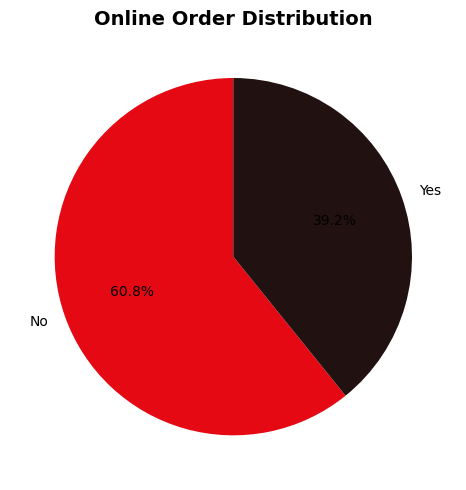

In [ ]:
import matplotlib.pyplot as plt
query = "SELECT online_order, COUNT(*) AS total FROM restaurants GROUP BY online_order"
result = pd.read_sql(query, conn)

plt.figure(figsize=(6,5))
plt.pie(result['total'], labels=result['online_order'],
        autopct='%1.1f%%', colors=['#E50914','#221111'],
        startangle=90)
plt.title('Online Order Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5487/3042500252.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x='votes', y='name', palette='Reds_r')


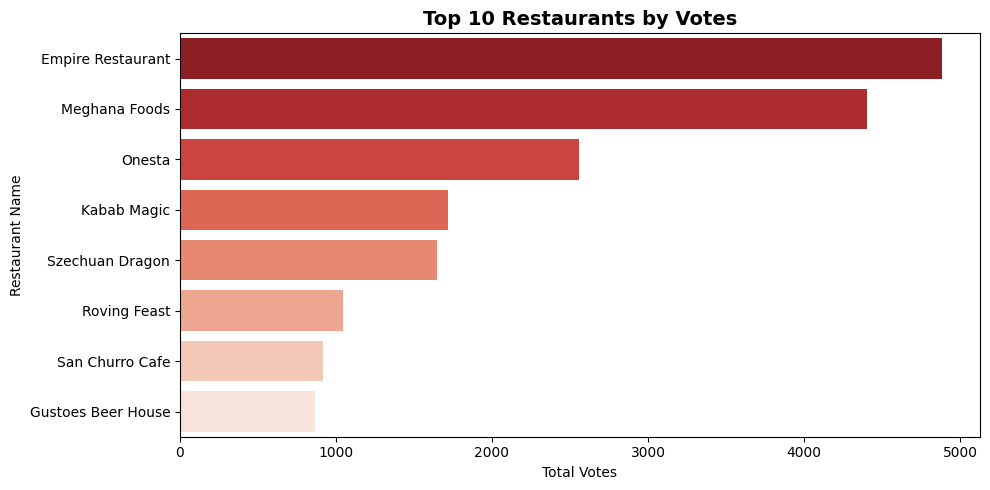

In [ ]:
query = "SELECT name, votes FROM restaurants ORDER BY votes DESC LIMIT 10"
result = pd.read_sql(query, conn)

plt.figure(figsize=(10,5))
sns.barplot(data=result, x='votes', y='name', palette='Reds_r')
plt.title('Top 10 Restaurants by Votes', fontsize=14, fontweight='bold')
plt.xlabel('Total Votes')
plt.ylabel('Restaurant Name')
plt.tight_layout()
plt.show()